# FMoE Dataset Profiles

This notebook summarizes the current main datasets for FMoE experiments:

- `KuaiRecSmall0.1`
- `lastfm0.03`
- `movielens1m`
- `retail_rocket`
- `foursquare`
- `amazon_beauty`

The notebook focuses on:

1. structural workload for session-based training
2. feature probe distributions relevant to routing
3. practical roles for each dataset in the FMoE workflow


In [1]:
from __future__ import annotations

import importlib.util
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")

REPO_ROOT = Path("/workspace/jy1559/FMoE")
TOOL_PATH = REPO_ROOT / "experiments/tools/analyze_dataset_profiles.py"
DATASETS = [
    "KuaiRecSmall0.1",
    "lastfm0.03",
    "movielens1m",
    "retail_rocket",
    "foursquare",
    "amazon_beauty",
]

spec = importlib.util.spec_from_file_location("dataset_profiles_tool", TOOL_PATH)
tool = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(tool)


In [2]:
results = {}
processed_root = REPO_ROOT / "Datasets/processed/feature_added_v2"

for dataset in DATASETS:
    inter_path = tool.resolve_inter_path(processed_root, dataset)
    meta_path = tool.resolve_meta_path(processed_root, dataset)
    df = tool.load_probe_df(inter_path)
    results[dataset] = {
        "structure": tool.summarize_structure(df),
        "probe": tool.summarize_probe_features(df),
        "raw_z": tool.load_raw_z_summary(meta_path),
        "inter_path": str(inter_path),
        "meta_path": str(meta_path),
    }

structure_df = pd.DataFrame({k: v["structure"] for k, v in results.items()}).T
probe_df = pd.DataFrame({k: {f: x["mean"] for f, x in v["probe"].items()} for k, v in results.items()}).T
raw_z_df = pd.DataFrame({k: {f: x["mean"] for f, x in v["raw_z"]["raw_z"].items()} for k, v in results.items()}).T
timestamp_unit = pd.Series({k: v["raw_z"]["timestamp_unit"] for k, v in results.items()}, name="timestamp_unit")

display(Markdown("## Structure Table"))
display(
    structure_df[
        [
            "rows",
            "sessions",
            "users",
            "items",
            "avg_session_len",
            "p90_session_len",
            "avg_sessions_per_user",
            "effective_tokens@10",
            "effective_tokens@30",
            "top10_item_share",
            "top100_item_share",
        ]
    ].style.format(
        {
            "rows": "{:,.0f}",
            "sessions": "{:,.0f}",
            "users": "{:,.0f}",
            "items": "{:,.0f}",
            "avg_session_len": "{:.2f}",
            "p90_session_len": "{:.1f}",
            "avg_sessions_per_user": "{:.2f}",
            "effective_tokens@10": "{:,.0f}",
            "effective_tokens@30": "{:,.0f}",
            "top10_item_share": "{:.3f}",
            "top100_item_share": "{:.3f}",
        }
    )
)


## Structure Table

,rows,sessions,users,items,avg_session_len,p90_session_len,avg_sessions_per_user,effective_tokens@10,effective_tokens@30,top10_item_share,top100_item_share
KuaiRecSmall0.1,"192,158","19,034",140,"3,207",10.10,18.0,135.96,"143,690","183,954",0.005,0.050
lastfm0.03,"470,408","25,089",130,"52,510",18.75,44.0,192.99,"223,542","405,183",0.005,0.026
movielens1m,"575,281","14,539","6,038","3,533",39.57,50.0,2.41,"141,199","383,957",0.040,0.243
retail_rocket,"821,243","153,092","124,922","90,211",5.36,9.0,1.23,"719,337","802,540",0.009,0.043
foursquare,"145,238","25,369","1,083","30,588",5.73,10.0,23.42,"124,747","141,913",0.026,0.100
amazon_beauty,"8,635",756,739,"3,970",11.42,22.0,1.02,"5,998","8,073",0.018,0.118


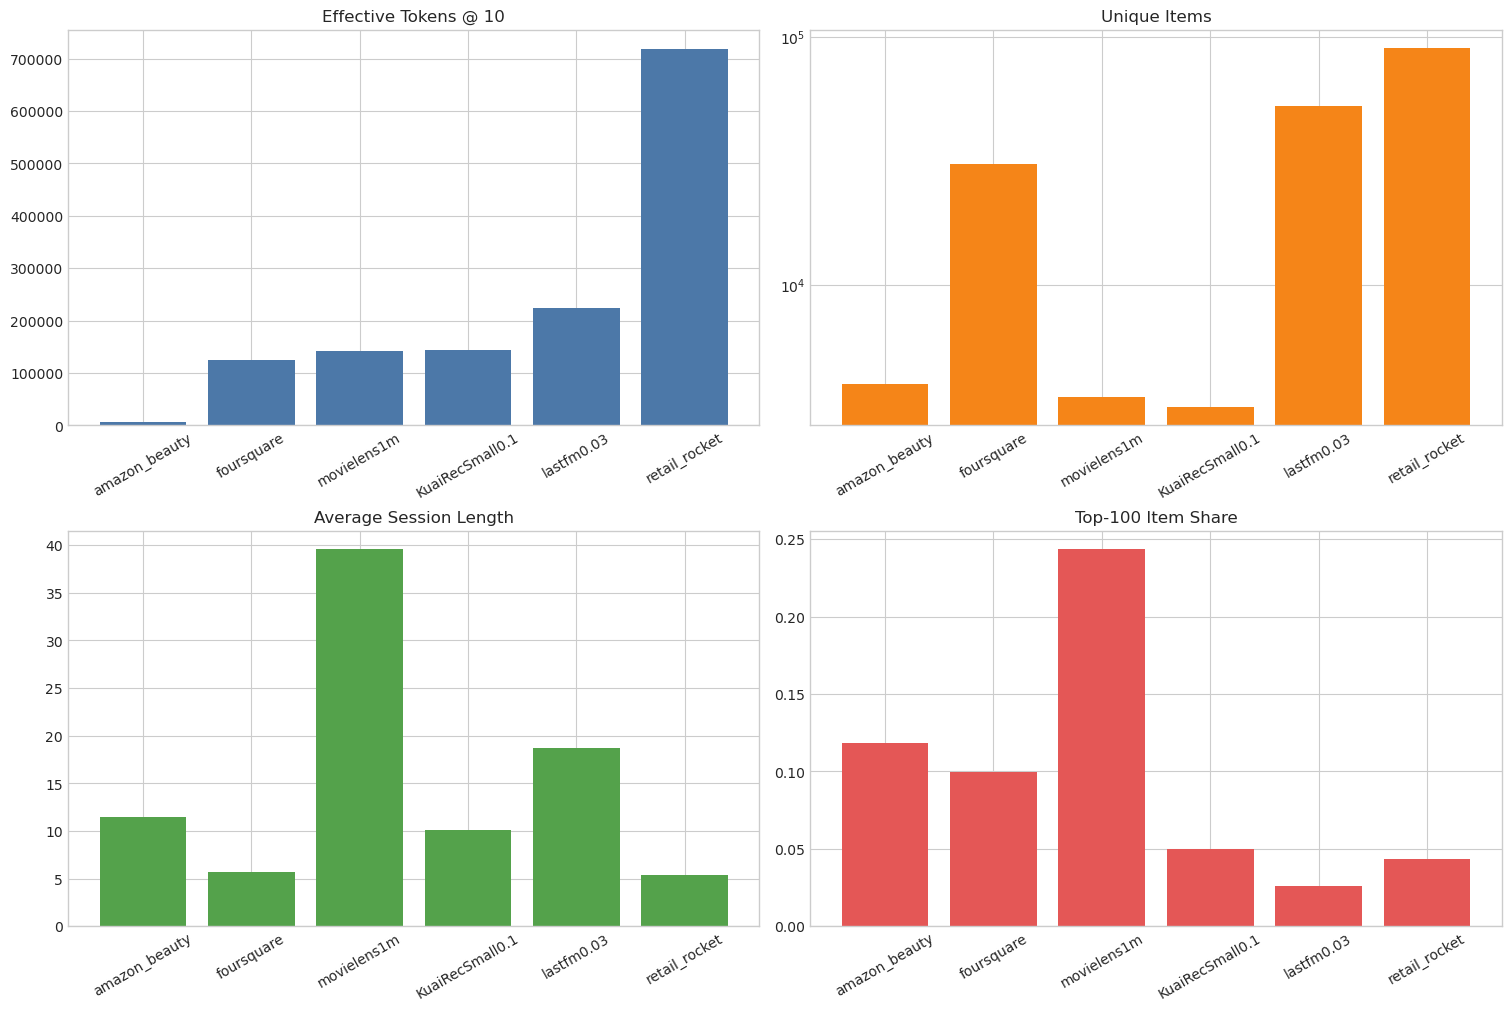

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

order = structure_df["effective_tokens@10"].sort_values().index.tolist()
plot_df = structure_df.loc[order]

axes[0, 0].bar(plot_df.index, plot_df["effective_tokens@10"], color="#4C78A8")
axes[0, 0].set_title("Effective Tokens @ 10")
axes[0, 0].tick_params(axis="x", rotation=30)

axes[0, 1].bar(plot_df.index, plot_df["items"], color="#F58518")
axes[0, 1].set_title("Unique Items")
axes[0, 1].set_yscale("log")
axes[0, 1].tick_params(axis="x", rotation=30)

axes[1, 0].bar(plot_df.index, plot_df["avg_session_len"], color="#54A24B")
axes[1, 0].set_title("Average Session Length")
axes[1, 0].tick_params(axis="x", rotation=30)

axes[1, 1].bar(plot_df.index, plot_df["top100_item_share"], color="#E45756")
axes[1, 1].set_title("Top-100 Item Share")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.show()


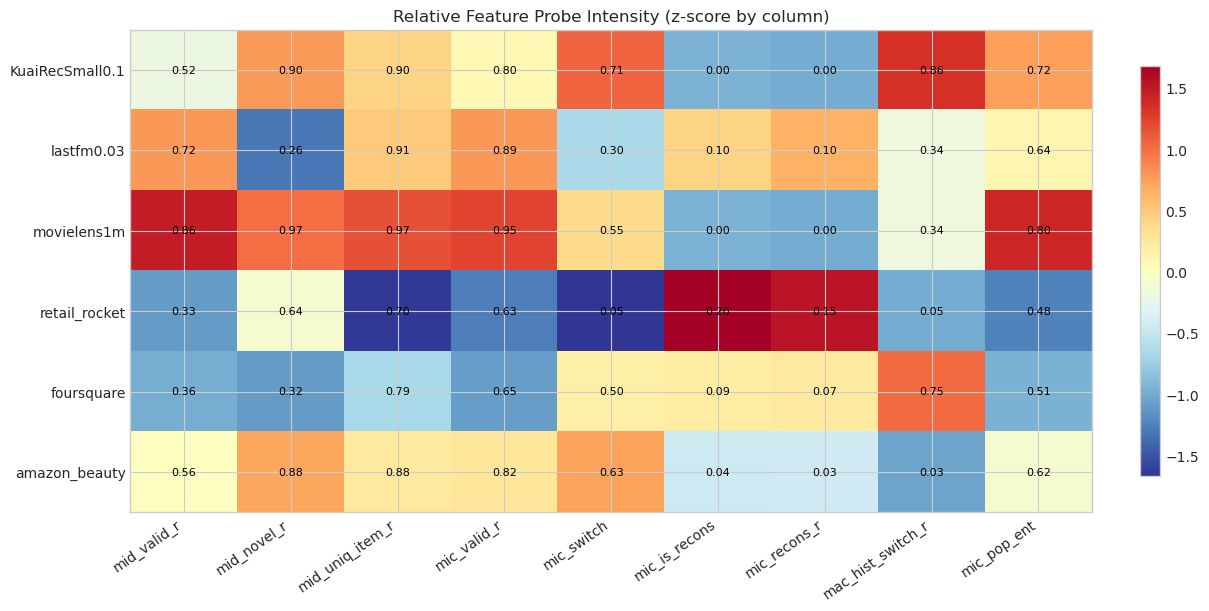

In [4]:
focus_features = [
    "mid_valid_r",
    "mid_novel_r",
    "mid_uniq_item_r",
    "mic_valid_r",
    "mic_switch",
    "mic_is_recons",
    "mic_recons_r",
    "mac_hist_switch_r",
    "mic_pop_ent",
]

heat = probe_df[focus_features].copy()
heat_z = (heat - heat.mean(axis=0)) / heat.std(axis=0).replace(0.0, 1.0)

fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
im = ax.imshow(heat_z.to_numpy(), cmap="RdYlBu_r", aspect="auto")
ax.set_xticks(np.arange(len(focus_features)))
ax.set_xticklabels(focus_features, rotation=35, ha="right")
ax.set_yticks(np.arange(len(heat_z.index)))
ax.set_yticklabels(heat_z.index)
ax.set_title("Relative Feature Probe Intensity (z-score by column)")

for i in range(heat_z.shape[0]):
    for j in range(heat_z.shape[1]):
        ax.text(j, i, f"{heat.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8, color="black")

fig.colorbar(im, ax=ax, shrink=0.85)
plt.show()


## Raw-Unit Feature Means

,mac_sess_gap,mac_hist_len,mac_hist_pop_avg,mid_sess_time,mid_int_avg,mid_pop_drift,mic_short_avg,mic_pop_drift
KuaiRecSmall0.1,8.187,6.331,2.401,5.291,2.676,0.364,2.985,0.363
lastfm0.03,15.778,15.555,1.130,14.178,10.091,0.301,10.669,0.295
movielens1m,1.158,4.735,2.493,6.650,1.949,1.805,2.020,1.790
retail_rocket,4.470,3.719,0.495,10.365,5.168,1.095,5.618,1.095
foursquare,10.991,9.862,0.955,7.961,3.600,0.320,3.951,0.311
amazon_beauty,0.469,0.614,0.014,19.270,10.733,0.448,11.912,0.467


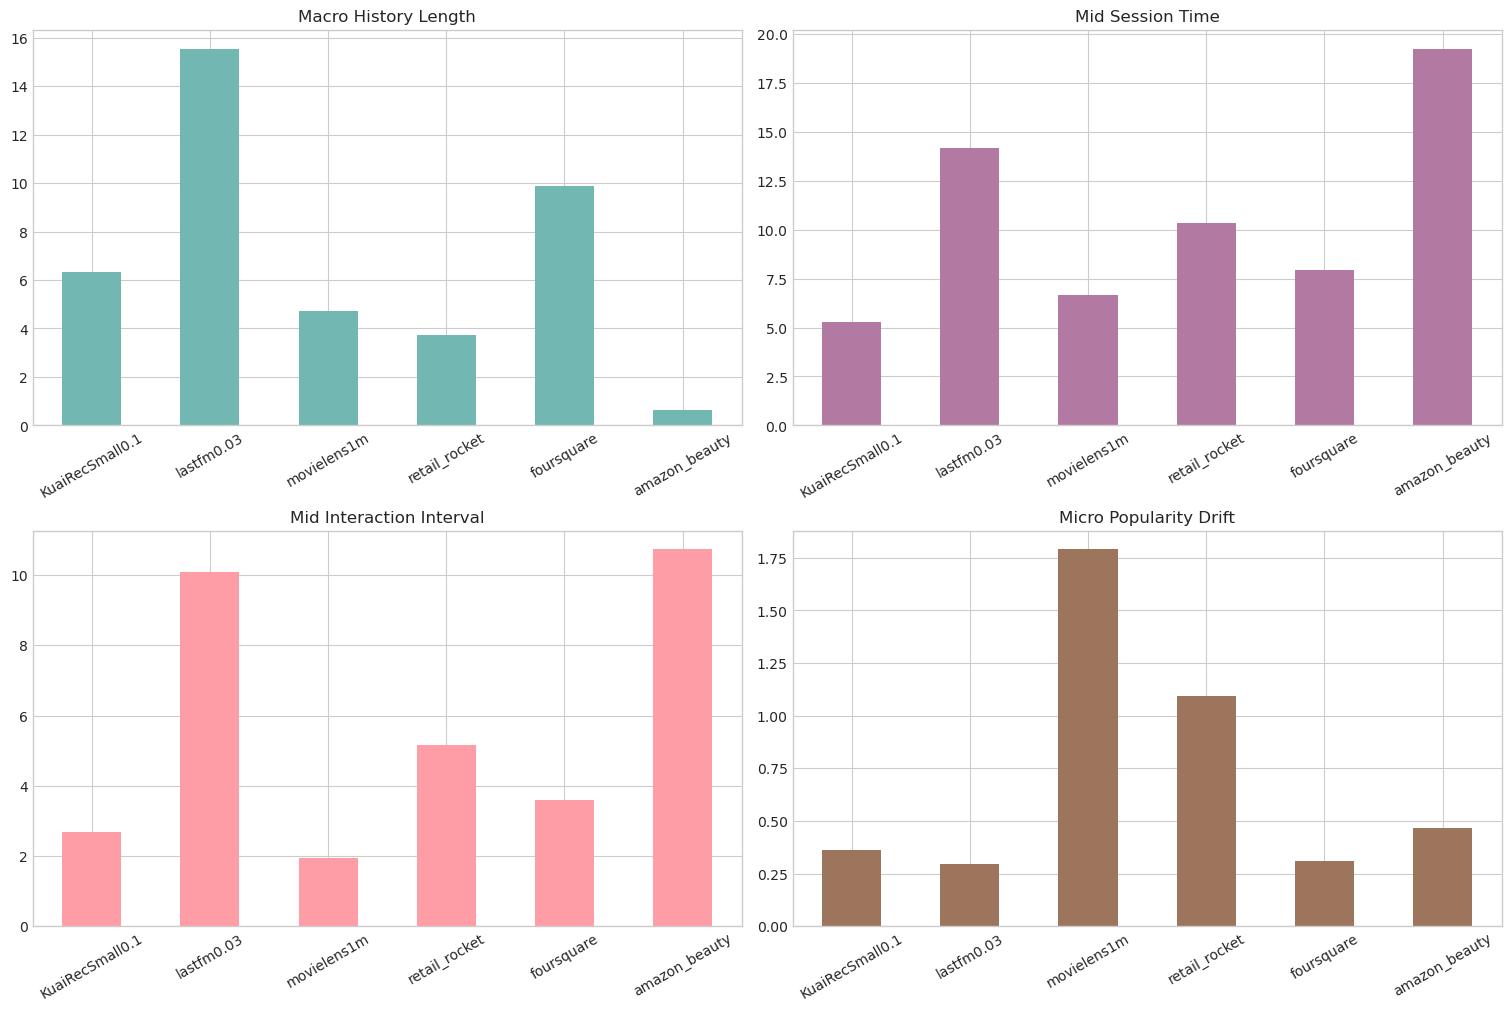

In [5]:
raw_focus = [
    "mac_sess_gap",
    "mac_hist_len",
    "mac_hist_pop_avg",
    "mid_sess_time",
    "mid_int_avg",
    "mid_pop_drift",
    "mic_short_avg",
    "mic_pop_drift",
]

raw_plot = raw_z_df[raw_focus].copy()
display(Markdown("## Raw-Unit Feature Means"))
display(raw_plot.style.format("{:.3f}"))

fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

raw_plot["mac_hist_len"].plot(kind="bar", ax=axes[0, 0], color="#72B7B2", title="Macro History Length")
raw_plot["mid_sess_time"].plot(kind="bar", ax=axes[0, 1], color="#B279A2", title="Mid Session Time")
raw_plot["mid_int_avg"].plot(kind="bar", ax=axes[1, 0], color="#FF9DA6", title="Mid Interaction Interval")
raw_plot["mic_pop_drift"].plot(kind="bar", ax=axes[1, 1], color="#9D755D", title="Micro Popularity Drift")

for ax in axes.flat:
    ax.tick_params(axis="x", rotation=30)

plt.show()


In [6]:
summary_rows = []
for dataset in DATASETS:
    s = structure_df.loc[dataset]
    p = probe_df.loc[dataset]
    if dataset == "KuaiRecSmall0.1":
        role = "main_dev"
        note = "Fast enough, strong novelty and switch signals."
    elif dataset == "lastfm0.03":
        role = "main_dev_plus"
        note = "Longer sessions, stronger tail, better for long-horizon routing."
    elif dataset == "movielens1m":
        role = "smoke_anchor"
        note = "Dense and popularity-heavy; good for quick sanity checks."
    elif dataset == "retail_rocket":
        role = "transfer_check"
        note = "Short sparse sessions; best for final robustness transfer."
    elif dataset == "foursquare":
        role = "semantic_probe"
        note = "Short but high transition behavior; useful for category-aware routing."
    else:
        role = "light_aux"
        note = "Cheap and compact; useful for fast external regression."

    summary_rows.append(
        {
            "dataset": dataset,
            "role": role,
            "eff@10": int(s["effective_tokens@10"]),
            "avg_sess": round(float(s["avg_session_len"]), 2),
            "items": int(s["items"]),
            "mid_novel": round(float(p["mid_novel_r"]), 3),
            "mic_switch": round(float(p["mic_switch"]), 3),
            "mic_recons": round(float(p["mic_is_recons"]), 3),
            "top100_share": round(float(s["top100_item_share"]), 3),
            "note": note,
        }
    )

role_df = pd.DataFrame(summary_rows).set_index("dataset")
display(Markdown("## FMoE-Oriented Role Suggestions"))
display(role_df)


## FMoE-Oriented Role Suggestions

,role,eff@10,avg_sess,items,mid_novel,mic_switch,mic_recons,top100_share,note
dataset,,,,,,,,,
KuaiRecSmall0.1,main_dev,143690,10.10,3207,0.901,0.712,0.000,0.050,"Fast enough, strong novelty and switch signals."
lastfm0.03,main_dev_plus,223542,18.75,52510,0.257,0.295,0.102,0.026,"Longer sessions, stronger tail, better for lon..."
movielens1m,smoke_anchor,141199,39.57,3533,0.975,0.546,0.000,0.243,Dense and popularity-heavy; good for quick san...
retail_rocket,transfer_check,719337,5.36,90211,0.635,0.048,0.196,0.043,Short sparse sessions; best for final robustne...
foursquare,semantic_probe,124747,5.73,30588,0.321,0.496,0.086,0.100,Short but high transition behavior; useful for...
amazon_beauty,light_aux,5998,11.42,3970,0.882,0.634,0.037,0.118,Cheap and compact; useful for fast external re...


## Reading Guide

- `effective_tokens@10` is the closest proxy to actual training load when the model keeps the latest 10 items.
- `top100_item_share` is a quick popularity concentration check.
- `mid_novel_r`, `mic_switch`, and `mic_is_recons` are useful for deciding whether the router should emphasize novelty, transition, or repetition.
- `lastfm0.03` and `KuaiRecSmall0.1` are the most informative pair for the next flat-router FMoE cycle.
